<a href="https://colab.research.google.com/github/Bamboohoccode/LLMs_From_Scratch/blob/main/Chapter_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

# Import data

In [13]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    print("Total number of character:", len(raw_text))
    print(raw_text[:99])


Total number of character: 20505
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [14]:
len(raw_text)


20505

In [15]:
def text_unique(text):
    unique = {}
    unique = set()
    for char in text:
        unique.add(char)
    return unique

In [16]:
unique = text_unique(raw_text)
unique

{'\n',
 ' ',
 '!',
 '"',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 ':',
 ';',
 '?',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'L',
 'M',
 'N',
 'O',
 'P',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'Y',
 '_',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z'}

# Try to use re.split()

In [ ]:
import re
text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)
result

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']

[Xem thông tin về re.split](https://gemini.google.com/share/e61f570b0efb)

In [ ]:
re.split(r'([,.])',text)

['Hello', ',', ' world', '.', ' This', ',', ' is a test', '.', '']

# 1) Preprocessing

In [ ]:
preprocessed_text = re.split(r'([,.:;?_!"()\']|--|\s)',raw_text)
print(preprocessed_text)
preprocessed_text = [item for item in preprocessed_text if item.strip()]
print(preprocessed_text)

['I', ' ', 'HAD', ' ', 'always', ' ', 'thought', ' ', 'Jack', ' ', 'Gisburn', ' ', 'rather', ' ', 'a', ' ', 'cheap', ' ', 'genius', '--', 'though', ' ', 'a', ' ', 'good', ' ', 'fellow', ' ', 'enough', '--', 'so', ' ', 'it', ' ', 'was', ' ', 'no', ' ', 'great', ' ', 'surprise', ' ', 'to', ' ', 'me', ' ', 'to', ' ', 'hear', ' ', 'that', ',', '', ' ', 'in', ' ', 'the', ' ', 'height', ' ', 'of', ' ', 'his', ' ', 'glory', ',', '', ' ', 'he', ' ', 'had', ' ', 'dropped', ' ', 'his', ' ', 'painting', ',', '', ' ', 'married', ' ', 'a', ' ', 'rich', ' ', 'widow', ',', '', ' ', 'and', ' ', 'established', ' ', 'himself', ' ', 'in', ' ', 'a', ' ', 'villa', ' ', 'on', ' ', 'the', ' ', 'Riviera', '.', '', ' ', '', '(', 'Though', ' ', 'I', ' ', 'rather', ' ', 'thought', ' ', 'it', ' ', 'would', ' ', 'have', ' ', 'been', ' ', 'Rome', ' ', 'or', ' ', 'Florence', '.', '', ')', '', '\n', '', '\n', '', '"', 'The', ' ', 'height', ' ', 'of', ' ', 'his', ' ', 'glory', '"', '', '--', 'that', ' ', 'was', ' ', '

In [ ]:
all_words = sorted(list(set(preprocessed_text)))

In [ ]:
all_words

['!',
 '"',
 "'",
 '(',
 ')',
 ',',
 '--',
 '.',
 '/',
 '0',
 '1',
 ':',
 ';',
 '?',
 'A',
 'Ah',
 'Among',
 'And',
 'Are',
 'Arrt',
 'As',
 'At',
 'Be',
 'Begin',
 'Beta',
 'Burlington',
 'But',
 'By',
 'Carlo',
 'Chicago',
 'Claude',
 'Come',
 'Croft',
 'Destroyed',
 'Devonshire',
 'Don',
 'Dubarry',
 'Emperors',
 'Florence',
 'For',
 'Gallery',
 'Gideon',
 'Gisburn',
 'Gisburns',
 'Grafton',
 'Greek',
 'Grindle',
 'Grindles',
 'HAD',
 'Had',
 'Hang',
 'Has',
 'He',
 'Her',
 'Hermia',
 'His',
 'How',
 'I',
 'If',
 'In',
 'It',
 'Jack',
 'Jove',
 'Just',
 'Lord',
 'Made',
 'Miss',
 'Money',
 'Monte',
 'Moon-dancers',
 'Mr',
 'Mrs',
 'My',
 'Never',
 'No',
 'Now',
 'Nutley',
 'Of',
 'Oh',
 'On',
 'Once',
 'Only',
 'Or',
 'Perhaps',
 'Poor',
 'Professional',
 'Renaissance',
 'Rickham',
 'Riviera',
 'Rome',
 'Russian',
 'Sevres',
 'She',
 'Stroud',
 'Strouds',
 'Suddenly',
 'That',
 'The',
 'Then',
 'There',
 'They',
 'This',
 'Those',
 'Though',
 'Thwing',
 'Thwings',
 'To',
 'Usually',

In [ ]:
vocab_size = len(all_words)

In [ ]:
vocab_to_ind = {item:token for token,item in enumerate(all_words)}
vocab_to_ind

{'!': 0,
 '"': 1,
 "'": 2,
 '(': 3,
 ')': 4,
 ',': 5,
 '--': 6,
 '.': 7,
 '/': 8,
 '0': 9,
 '1': 10,
 ':': 11,
 ';': 12,
 '?': 13,
 'A': 14,
 'Ah': 15,
 'Among': 16,
 'And': 17,
 'Are': 18,
 'Arrt': 19,
 'As': 20,
 'At': 21,
 'Be': 22,
 'Begin': 23,
 'Beta': 24,
 'Burlington': 25,
 'But': 26,
 'By': 27,
 'Carlo': 28,
 'Chicago': 29,
 'Claude': 30,
 'Come': 31,
 'Croft': 32,
 'Destroyed': 33,
 'Devonshire': 34,
 'Don': 35,
 'Dubarry': 36,
 'Emperors': 37,
 'Florence': 38,
 'For': 39,
 'Gallery': 40,
 'Gideon': 41,
 'Gisburn': 42,
 'Gisburns': 43,
 'Grafton': 44,
 'Greek': 45,
 'Grindle': 46,
 'Grindles': 47,
 'HAD': 48,
 'Had': 49,
 'Hang': 50,
 'Has': 51,
 'He': 52,
 'Her': 53,
 'Hermia': 54,
 'His': 55,
 'How': 56,
 'I': 57,
 'If': 58,
 'In': 59,
 'It': 60,
 'Jack': 61,
 'Jove': 62,
 'Just': 63,
 'Lord': 64,
 'Made': 65,
 'Miss': 66,
 'Money': 67,
 'Monte': 68,
 'Moon-dancers': 69,
 'Mr': 70,
 'Mrs': 71,
 'My': 72,
 'Never': 73,
 'No': 74,
 'Now': 75,
 'Nutley': 76,
 'Of': 77,
 'Oh': 

In [ ]:
class SimpleTokenizerV1():
    def __init__(self,vocab_to_ind):
        self.v2i = vocab_to_ind
        self.i2v = {ind : item for item,ind in vocab_to_ind.items()}
    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)',text)
        preprocessed = [item for item in preprocessed if item.strip()]
        ids = [self.v2i[i] for i in preprocessed]
        return ids
    def decode(self,ids):
        text = " ".join([self.i2v[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text) #E
        return text


In [ ]:
tokenizer = SimpleTokenizerV1(vocab_to_ind)
ids = tokenizer.encode("I thought Jack")
ids

[57, 1008, 61]

In [ ]:
tokenizer.decode(ids)

'I thought Jack'

In [ ]:
text = "Hello, do you like tea?"
print(tokenizer.encode(text))

KeyError: 'Hello'

# 2.5 BPE

In [17]:
pip install tiktoken

In [18]:
from importlib.metadata import version
import tiktoken
print("tiktoken version:",version("tiktoken"))

tiktoken version: 0.12.0


In [19]:
tokenizer_gpt2 = tiktoken.get_encoding("gpt2")

In [20]:
# Dù có những từ không có trong từ điển như dùng BPE vẫn có thể encode nó được.
text = "Hello, tung do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace"
ind = tokenizer_gpt2.encode(text,allowed_special = {"<|endoftext|>"})
ind

[15496,
 11,
 256,
 2150,
 466,
 345,
 588,
 8887,
 30,
 220,
 50256,
 554,
 262,
 4252,
 18250,
 8812,
 2114,
 286,
 617,
 34680,
 27271]

In [21]:
strings = tokenizer_gpt2.decode(ind)
strings

'Hello, tung do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace'

# 2.6 Data sampling with sliding window.

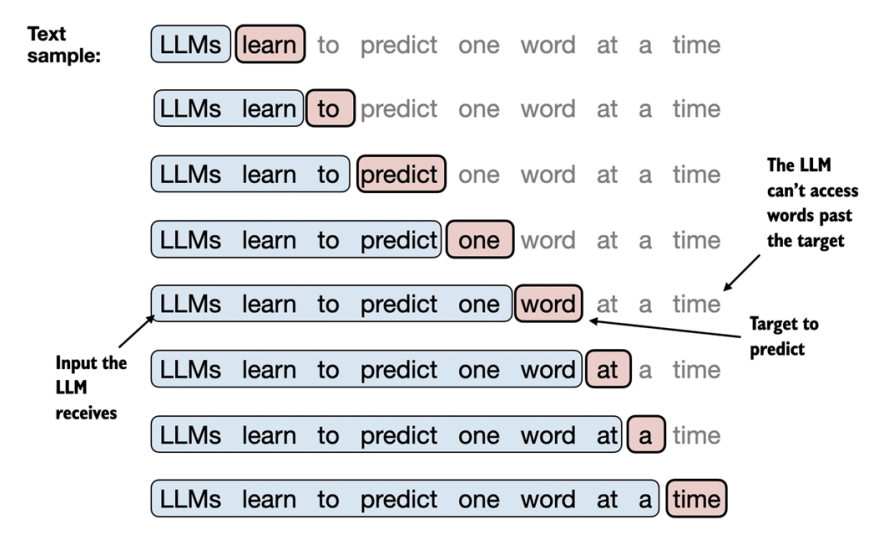

In [22]:
enc_text = tokenizer_gpt2.encode(raw_text)
len(enc_text)

5156

In [23]:
for i in range(1,10):
    context = enc_text[:i]
    desired = enc_text[i]
    print(tokenizer_gpt2.decode(context),"-->",tokenizer_gpt2.decode([desired]))


I -->  H
I H --> AD
I HAD -->  always
I HAD always -->  thought
I HAD always thought -->  Jack
I HAD always thought Jack -->  G
I HAD always thought Jack G --> is
I HAD always thought Jack Gis --> burn
I HAD always thought Jack Gisburn -->  rather


In [25]:
unk_words ="Akwirw ier"
ids = tokenizer_gpt2.encode(unk_words)
print(tokenizer_gpt2.decode(ids))

Akwirw ier


Bây giờ sẽ xây dựng class Dataset

In [43]:
import torch
from torch.utils.data import Dataset,DataLoader
class GPTDataSetV1(Dataset):
    def __init__(self,text,tokenizer,max_length,stride):
        self.input_ids = []
        self.target_ids = []

        ids = tokenizer.encode(text)
        for i in range(0,len(ids) - max_length,stride):
            input_indices = ids[i:i + max_length]
            target_indices = ids[i+1 : i + 1 + max_length]
            self.input_ids.append(torch.tensor(input_indices))
            self.target_ids.append(torch.tensor(target_indices))
    def __len__(self):
        return len(self.input_ids)
    def __getitem__(self,index):
        return self.input_ids[index],self.target_ids[index]

def dataloaderV1(text,batch_size=4, max_length=256,stride=128, shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tokenizer_gpt2
    Dataset = GPTDataSetV1(text,tokenizer,max_length,stride)
    dataloader = DataLoader(Dataset,batch_size,shuffle,drop_last=drop_last,num_workers=num_workers)
    return dataloader


In [45]:
BATCH_SIZE = 1
MAX_LENGTH = 5
STRIDE = 2
dataloader = dataloaderV1(raw_text,BATCH_SIZE,MAX_LENGTH,STRIDE,False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
sec_batch = next(data_iter)
print("first Batch\n",first_batch)
print("Second Batch\n",sec_batch)



first Batch
 [tensor([[  40,  367, 2885, 1464, 1807]]), tensor([[ 367, 2885, 1464, 1807, 3619]])]
Second Batch
 [tensor([[2885, 1464, 1807, 3619,  402]]), tensor([[1464, 1807, 3619,  402,  271]])]


# 2.7 Creating token embedding

Little example

In [58]:
vocab_size = 6
output_dim = 3
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

embedding_layer(torch.tensor([3])) # Input must be smaller than vocab_size

# embed_matrix
embedding_layer.weight

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)

In [61]:
input_ids = torch.tensor([2, 3, 5, 1])
embedding_layer(input_ids)

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)

In [63]:
vocab_size = 50257
vocab_dims = 256
token_embedding_layer = torch.nn.Embedding(vocab_size,vocab_dims)


In [68]:
max_length = 4
dataloader = dataloaderV1(
raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print(inputs)
print(inputs.shape)

tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
torch.Size([8, 4])


Each token --> 256.

In [70]:
token_embedding = token_embedding_layer(inputs)
print(token_embedding.shape)

torch.Size([8, 4, 256])


In [72]:
pos_embedding_layer = torch.nn.Embedding(vocab_size,vocab_dims)
pos_embedding = pos_embedding_layer(torch.arange(max_length)) # Quan trọng !!!!!!!!!!
print(pos_embedding.shape)

torch.Size([4, 256])


In [74]:
input_embedding = token_embedding + pos_embedding
print(input_embedding.shape)

torch.Size([8, 4, 256])
